In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
import sys
import pickle
import argparse
import importlib
import torch
from torch.utils.data import DataLoader

# --------------------------------------------------------------------------- #
# 1.1 Paths (Dynamic)
# --------------------------------------------------------------------------- #
# Get the directory where this notebook is currently located
BASE_DIR = os.path.abspath(os.getcwd())

DATA_DIR   = os.path.join(BASE_DIR, "Data")
PTB_DIR    = os.path.join(DATA_DIR, "Cough_PTB")
NONPTB_DIR = os.path.join(DATA_DIR, "Cough_Non-PTB")
FOLD_ROOT  = os.path.join(BASE_DIR, "json_folds_5skf")
N_RUNS     = 5
RUN_VAL_SIZE = 0.25
RANDOM_STATE = 42

SRC_DIR = os.path.join(BASE_DIR, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Now these will work!
import dataloader as ast_dataloader
import models
import models.ast_models as _ast_models_module
import traintest as _traintest_module

importlib.reload(_traintest_module)
importlib.reload(ast_dataloader)
importlib.reload(_ast_models_module)
importlib.reload(models)

from traintest import train

# --------------------------------------------------------------------------- #
# 1.2  Collect subject IDs and wav files
# --------------------------------------------------------------------------- #
def collect_patients(directory, label_str):
    patients = defaultdict(list)
    for wav_path in sorted(glob.glob(os.path.join(directory, "*.wav"))):
        filename = os.path.basename(wav_path)
        patient_id = filename.split("_")[0]
        patients[patient_id].append({
            "wav": wav_path.replace("\\", "/"),
            "labels": label_str
        })
    return patients

ptb_patients = collect_patients(PTB_DIR, label_str="1")
nonptb_patients = collect_patients(NONPTB_DIR, label_str="0")

ptb_ids = sorted(ptb_patients.keys())
nonptb_ids = sorted(nonptb_patients.keys())

print(f"PTB     patients ({len(ptb_ids):2d}): {ptb_ids}")
print(f"Non-PTB patients ({len(nonptb_ids):2d}): {nonptb_ids}")
print(f"Total patients  : {len(ptb_ids) + len(nonptb_ids)}\n")

# --------------------------------------------------------------------------- #
# 1.3  Build subject-level table
# --------------------------------------------------------------------------- #
subject_records = []
for pid in sorted(set(list(ptb_patients.keys()) + list(nonptb_patients.keys()))):
    label = 1 if pid in ptb_patients else 0
    subject_records.append({"subject_id": pid, "subject_label": label})

st = (
    pd.DataFrame(subject_records)
    .sort_values("subject_id")
    .reset_index(drop=True)
)

print(f"Subject table (st) shape: {st.shape}")
print(st.to_string())

# --------------------------------------------------------------------------- #
# 1.4  5-FOLD Stratified CV with inner stratified val split (same SI logic)
# --------------------------------------------------------------------------- #
def split_subject_ids_5skf(subject_table: pd.DataFrame, n_runs: int = 5, run_val_size: float = 0.25, random_seed: int = 42):
    x_subj = subject_table["subject_id"].values
    y_subj = subject_table["subject_label"].values
    outer_skf = StratifiedKFold(n_splits=n_runs, shuffle=True, random_state=random_seed)

    assignments = []
    for run_i, (train_val_idx, test_idx) in enumerate(outer_skf.split(x_subj, y_subj), start=1):
        train_val_ids = x_subj[train_val_idx]
        train_val_y = y_subj[train_val_idx]
        test_ids = x_subj[test_idx]

        inner_split = StratifiedShuffleSplit(
            n_splits=1,
            test_size=run_val_size,
            random_state=random_seed + run_i
        )
        inner_train_idx, inner_val_idx = next(inner_split.split(train_val_ids, train_val_y))

        tr_ids = sorted(train_val_ids[inner_train_idx].tolist())
        va_ids = sorted(train_val_ids[inner_val_idx].tolist())
        te_ids = sorted(test_ids.tolist())

        tr_set = set(tr_ids)
        va_set = set(va_ids)
        te_set = set(te_ids)
        leak_free = tr_set.isdisjoint(va_set) and tr_set.isdisjoint(te_set) and va_set.isdisjoint(te_set)
        print(f"{'✅' if leak_free else '❌'} Fold {run_i}: train/val/test subjects disjoint")

        assignments.append({
            "run": run_i,
            "seed": random_seed + run_i,
            "train": tr_ids,
            "val": va_ids,
            "test": te_ids,
        })
    return assignments

run_assignments = split_subject_ids_5skf(
    subject_table=st,
    n_runs=N_RUNS,
    run_val_size=RUN_VAL_SIZE,
    random_seed=RANDOM_STATE
)

# --------------------------------------------------------------------------- #
# 1.5  Helpers
# --------------------------------------------------------------------------- #
def patients_to_records(patient_ids, ptb_dict, nonptb_dict):
    records = []
    for pid in patient_ids:
        if pid in ptb_dict:
            records.extend(ptb_dict[pid])
        elif pid in nonptb_dict:
            records.extend(nonptb_dict[pid])
    return records

def save_json(records, filepath):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    with open(filepath, "w") as f:
        json.dump({"data": records}, f, indent=4)

# --------------------------------------------------------------------------- #
# 1.6  Save per-fold train/val/test JSON + summary
# --------------------------------------------------------------------------- #
print(f"\n{'=' * 72}")
print("STEP 1 — 5-FOLD SUBJECT-LEVEL STRATIFIED SPLIT (SI style)")
print("Fold ratio: Train 60% | Val 20% | Test 20%")
print(f"{'=' * 72}")

for ra in run_assignments:
    run_num = ra["run"]
    run_dir = os.path.join(FOLD_ROOT, f"run_{run_num}")

    train_records = patients_to_records(ra["train"], ptb_patients, nonptb_patients)
    val_records = patients_to_records(ra["val"], ptb_patients, nonptb_patients)
    test_records = patients_to_records(ra["test"], ptb_patients, nonptb_patients)

    save_json(train_records, os.path.join(run_dir, "train_data.json"))
    save_json(val_records, os.path.join(run_dir, "val_data.json"))
    save_json(test_records, os.path.join(run_dir, "test_data.json"))

    n_train_ptb = sum(1 for r in train_records if r["labels"] == "1")
    n_val_ptb = sum(1 for r in val_records if r["labels"] == "1")
    n_test_ptb = sum(1 for r in test_records if r["labels"] == "1")

    print(f"\n--- FOLD {run_num} (seed={ra['seed']}) ---")
    print(f"TRAIN: {len(ra['train']):2d} subjects -> {len(train_records):4d} files [{n_train_ptb} PTB / {len(train_records)-n_train_ptb} Non-PTB]")
    print(f"VAL  : {len(ra['val']):2d} subjects -> {len(val_records):4d} files [{n_val_ptb} PTB / {len(val_records)-n_val_ptb} Non-PTB]")
    print(f"TEST : {len(ra['test']):2d} subjects -> {len(test_records):4d} files [{n_test_ptb} PTB / {len(test_records)-n_test_ptb} Non-PTB]")
    print(f"IDs  -> TRAIN: {ra['train']} | VAL: {ra['val']} | TEST: {ra['test']}")

print(f"\n[✓] JSON files saved to: {FOLD_ROOT}")
print("[✓] Data preparation complete (5-Fold Subject-Level SKF).")

d:\AST-With-TB-Classify\.venv\lib\site-packages\torchaudio\extension\extension.py:13: UserWarning: torchaudio C++ extension is not available.
  warnings.warn('torchaudio C++ extension is not available.')
d:\AST-With-TB-Classify\.venv\lib\site-packages\torchaudio\backend\utils.py:89: UserWarning: No audio backend is available.
  warnings.warn('No audio backend is available.')


PTB     patients ( 7): ['006', '008', '009', '011', '012', '015', '016']
Non-PTB patients ( 8): ['001', '002', '003', '004', '005', '007', '013', '014']
Total patients  : 15

Subject table (st) shape: (15, 2)
   subject_id  subject_label
0         001              0
1         002              0
2         003              0
3         004              0
4         005              0
5         006              1
6         007              0
7         008              1
8         009              1
9         011              1
10        012              1
11        013              0
12        014              0
13        015              1
14        016              1
✅ Fold 1: train/val/test subjects disjoint
✅ Fold 2: train/val/test subjects disjoint
✅ Fold 3: train/val/test subjects disjoint
✅ Fold 4: train/val/test subjects disjoint
✅ Fold 5: train/val/test subjects disjoint

STEP 1 — 5-FOLD SUBJECT-LEVEL STRATIFIED SPLIT (SI style)
Fold ratio: Train 60% | Val 20% | Test 20%

--- FOLD 

d:\AST-With-TB-Classify\.venv\lib\site-packages\torch\cuda\amp\autocast_mode.py:118: UserWarning: torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.")


In [2]:
# =============================================================================
# STEP 2: MODEL CONFIGURATION & 5-FOLD TRAINING SETUP
# =============================================================================
# แต่ละ fold ใช้ run_X/train_data.json และ run_X/val_data.json (จาก STEP 1)
# โดย test_data.json จะถูกใช้ใน STEP 3 ของแต่ละ fold
#
# ★ Output: exp/tb_ast-p_KFold_No_augmented/run_X/
# =============================================================================

import sys
import os
import pickle
import argparse
import importlib
import torch
import numpy as np
from torch.utils.data import DataLoader

# --------------------------------------------------------------------------- #
# 2.1  เพิ่ม src/ directory เข้า sys.path
# --------------------------------------------------------------------------- #
SRC_DIR = os.path.join(BASE_DIR, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import dataloader as ast_dataloader
import models
import models.ast_models as _ast_models_module
import traintest as _traintest_module

importlib.reload(_traintest_module)
importlib.reload(ast_dataloader)
importlib.reload(_ast_models_module)
importlib.reload(models)

from traintest import train

# --------------------------------------------------------------------------- #
# 2.2  Paths
# --------------------------------------------------------------------------- #
LABEL_CSV = os.path.join(BASE_DIR, "class_labels_indices.csv")
EXP_ROOT  = os.path.join(BASE_DIR, "exp", "tb_ast-p_KFold_No_augmented")
NORM_MEAN = -4.527155
NORM_STD  =  5.118366

# --------------------------------------------------------------------------- #
# 2.3  Audio Configurations
# --------------------------------------------------------------------------- #
TRAIN_AUDIO_CONF = {
    "num_mel_bins": 128,
    "target_length": 100,
    "freqm":        0,
    "timem":        0,
    "mixup":        0.0,
    "dataset":      "audioset",
    "mode":         "train",
    "mean":        NORM_MEAN,
    "std":          NORM_STD,
    "noise":        False,
    "skip_norm": False
}

EVAL_AUDIO_CONF = {
    "num_mel_bins": 128,
    "target_length": 100,
    "freqm":        0,
    "timem":        0,
    "mixup":        0.0,
    "dataset":      "audioset",
    "mode":         "evaluation",
    "mean":        NORM_MEAN,
    "std":          NORM_STD,
    "noise":        False,
    "skip_norm": False
}

d:\AST-With-TB-Classify\.venv\lib\site-packages\torch\cuda\amp\autocast_mode.py:118: UserWarning: torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.")


In [3]:
import copy

# --------------------------------------------------------------------------- #
# 2.4  Training Arguments
# --------------------------------------------------------------------------- #
def make_training_args(run_exp_dir, n_epochs=20):
    return argparse.Namespace(
        exp_dir           = run_exp_dir,
        dataset           = "audioset",
        n_class           = 2,
        lr                = 1e-5,
        n_epochs          = n_epochs,
        batch_size        = 8,
        n_print_steps     = 10,
        save_model        = True,
        metrics           = "mAP",
        loss              = "CE",
        warmup            = False,
        lrscheduler_start = 5,
        lrscheduler_step  = 1,
        lrscheduler_decay = 0.85,
        wa                = True,
        wa_start          = 5,
        wa_end            = n_epochs,
    )

def prune_epoch_checkpoints(run_exp_dir):
    model_dir = os.path.join(run_exp_dir, "models")
    keep_files = {"audio_model_wa.pth", "best_audio_model.pth", "best_optim_state.pth"}
    removed = 0
    if not os.path.isdir(model_dir):
        return removed
    for name in os.listdir(model_dir):
        if not name.endswith(".pth") or name in keep_files:
            continue
        # Keep only important files; remove per-epoch checkpoints.
        if name.startswith("audio_model.") or name.startswith("optim_state."):
            os.remove(os.path.join(model_dir, name))
            removed += 1
    return removed

# Prepare AST initialization once to avoid repeated pretrain download/check in each fold.
print("\nPreparing shared AST initialization...")
seed_model = models.ASTModel(
    label_dim         = 2,
    fstride           = 10,
    tstride           = 10,
    input_fdim        = 128,
    input_tdim        = 100,
    imagenet_pretrain = True,
    audioset_pretrain = True,
    model_size        = "base384",
    verbose           = False
)
seed_state_dict = copy.deepcopy(seed_model.state_dict())
del seed_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Shared initialization ready.\n")

# --------------------------------------------------------------------------- #
# 2.5  5-FOLD TRAINING LOOP
# --------------------------------------------------------------------------- #
print("=" * 65)
print("  AST-P  |  5-FOLD SUBJECT-LEVEL SKF TRAINING")
print("  Strategy: Train 60% | Val 20% | Test 20% per fold")
print("=" * 65)
print(f"  Device  : {'CUDA (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")
print(f"  Epochs  : 20  |  LR: 1e-5  |  Batch: 8  |  WA: epoch 10→20")
print("=" * 65)

for ra in run_assignments:
    run_num = ra["run"]

    print(f"\n{'━'*65}")
    print(f"  ▶  FOLD {run_num} / {N_RUNS}  TRAINING START  (seed={ra['seed']})")
    print(f"{'━'*65}")

    run_data_dir = os.path.join(FOLD_ROOT, f"run_{run_num}")
    run_exp_dir  = os.path.join(EXP_ROOT,  f"run_{run_num}")
    os.makedirs(os.path.join(run_exp_dir, "models"),      exist_ok=True)
    os.makedirs(os.path.join(run_exp_dir, "predictions"), exist_ok=True)

    train_json = os.path.join(run_data_dir, "train_data.json")
    val_json   = os.path.join(run_data_dir, "val_data.json")

    train_dataset = ast_dataloader.AudiosetDataset(
        train_json, audio_conf=TRAIN_AUDIO_CONF, label_csv=LABEL_CSV)
    train_loader  = DataLoader(
        train_dataset, batch_size=8, shuffle=True,
        num_workers=0, pin_memory=torch.cuda.is_available())

    val_dataset = ast_dataloader.AudiosetDataset(
        val_json, audio_conf=EVAL_AUDIO_CONF, label_csv=LABEL_CSV)
    val_loader  = DataLoader(
        val_dataset, batch_size=16, shuffle=False,
        num_workers=0, pin_memory=torch.cuda.is_available())

    print(f"\n  [Data] Train: {len(train_dataset)} files | Val: {len(val_dataset)} files")

    audio_model = models.ASTModel(
        label_dim         = 2,
        fstride           = 10,
        tstride           = 10,
        input_fdim        = 128,
        input_tdim        = 100,
        imagenet_pretrain = False,
        audioset_pretrain = False,
        model_size        = "base384",
        verbose           = False
    )
    audio_model.load_state_dict(seed_state_dict, strict=True)

    args = make_training_args(run_exp_dir, n_epochs=20)
    with open(os.path.join(run_exp_dir, "args.pkl"), "wb") as f:
        pickle.dump(args, f)

    print(f"  [Model] AST-P created → output: {run_exp_dir}")
    print(f"  [Training] Starting {args.n_epochs} epochs...\n")

    train(audio_model, train_loader, val_loader, args)

    removed_count = prune_epoch_checkpoints(run_exp_dir)
    print(f"  [Cleanup] Removed {removed_count} per-epoch .pth files (kept WA + best).")

    print(f"\n  [✓] FOLD {run_num} training complete.")
    print(f"      Results  → {run_exp_dir}/result.csv")
    print(f"      WA Model → {run_exp_dir}/models/audio_model_wa.pth")

print(f"\n{'═'*65}")
print("  [✓] ALL FOLDS TRAINING COMPLETE")
print(f"{'═'*65}")


Preparing shared AST initialization...
Shared initialization ready.

  AST-P  |  5-FOLD SUBJECT-LEVEL SKF TRAINING
  Strategy: Train 60% | Val 20% | Test 20% per fold
  Device  : CPU
  Epochs  : 20  |  LR: 1e-5  |  Batch: 8  |  WA: epoch 10→20

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▶  FOLD 1 / 5  TRAINING START  (seed=43)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
---------------the train dataloader---------------
now using following mask: 0 freq, 0 time
now using mix-up with rate 0.000000
now process audioset
use dataset mean -4.527 and std 5.118 to normalize the input.
number of classes is 2
---------------the evaluation dataloader---------------
now using following mask: 0 freq, 0 time
now using mix-up with rate 0.000000
now process audioset
use dataset mean -4.527 and std 5.118 to normalize the input.
number of classes is 2

  [Data] Train: 258 files | Val: 170 files
  [Model] AST-P created → output: d:\AST-With-TB-Classify\exp\

d:\AST-With-TB-Classify\.venv\lib\site-packages\torch\cuda\amp\grad_scaler.py:116: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.")
d:\AST-With-TB-Classify\src\dataloader.py:111: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, samples = wavfile.read(path)


Epoch: [1][10/33]	Per Sample Total Time 1.52241	Per Sample Data Time 0.01015	Per Sample DNN Time 1.51226	Train Loss 0.5232	
Epoch: [1][20/33]	Per Sample Total Time 1.50192	Per Sample Data Time 0.01177	Per Sample DNN Time 1.49015	Train Loss 0.4127	
Epoch: [1][30/33]	Per Sample Total Time 1.52396	Per Sample Data Time 0.01244	Per Sample DNN Time 1.51153	Train Loss 0.3481	
start validation
mAP: 0.516283
AUC: 0.544333
Avg Precision: 0.500348
Avg Recall: 1.000000
d_prime: 0.157482
train_loss: 0.339677
valid_loss: 0.600182
validation finished
Epoch-1 lr: 1e-05
epoch 1 training time: 476.159
---------------
2026-04-07 23:38:03.215572
current #epochs=2, #steps=33


d:\AST-With-TB-Classify\src\dataloader.py:111: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, samples = wavfile.read(path)
d:\AST-With-TB-Classify\.venv\lib\site-packages\torch\cuda\amp\autocast_mode.py:118: UserWarning: torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.")


Epoch: [2][7/33]	Per Sample Total Time 1.53285	Per Sample Data Time 0.01321	Per Sample DNN Time 1.51964	Train Loss 0.1299	
Epoch: [2][17/33]	Per Sample Total Time 1.48410	Per Sample Data Time 0.01269	Per Sample DNN Time 1.47141	Train Loss 0.0797	
Epoch: [2][27/33]	Per Sample Total Time 1.42501	Per Sample Data Time 0.01080	Per Sample DNN Time 1.41420	Train Loss 0.0608	
start validation
mAP: 0.511292
AUC: 0.561333
Avg Precision: 0.502152
Avg Recall: 1.000000
d_prime: 0.218285
train_loss: 0.055240
valid_loss: 0.633385
validation finished
Epoch-2 lr: 1e-05
epoch 2 training time: 437.344
---------------
2026-04-07 23:45:20.559993
current #epochs=3, #steps=66


...

Epoch: [19][0/35]	Per Sample Total Time 0.92013	Per Sample Data Time 0.00340	Per Sample DNN Time 0.91673	Train Loss 0.0001	
Epoch: [19][10/35]	Per Sample Total Time 0.91687	Per Sample Data Time 0.00283	Per Sample DNN Time 0.91405	Train Loss 0.0004	
Epoch: [19][20/35]	Per Sample Total Time 0.91722	Per Sample Data Time 0.00280	Per Sample DNN Time 0.91443	Train Loss 0.0003	
Epoch: [19][30/35]	Per Sample Total Time 0.91713	Per Sample Data Time 0.00290	Per Sample DNN Time 0.91424	Train Loss 0.0003	
start validation
mAP: 0.445937
AUC: 0.310833
Avg Precision: 0.503431
Avg Recall: 1.000000
d_prime: -0.697900
train_loss: 0.000311
valid_loss: 0.529877
validation finished
Epoch-19 lr: 8.735421910125168e-07
epoch 19 training time: 287.106
---------------
2026-04-08 08:16:14.289711
current #epochs=20, #steps=665


d:\AST-With-TB-Classify\src\dataloader.py:111: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, samples = wavfile.read(path)
d:\AST-With-TB-Classify\.venv\lib\site-packages\torch\cuda\amp\autocast_mode.py:118: UserWarning: torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.")


Epoch: [20][5/35]	Per Sample Total Time 0.92110	Per Sample Data Time 0.00282	Per Sample DNN Time 0.91828	Train Loss 0.0005	
Epoch: [20][15/35]	Per Sample Total Time 0.92035	Per Sample Data Time 0.00291	Per Sample DNN Time 0.91744	Train Loss 0.0004	
Epoch: [20][25/35]	Per Sample Total Time 0.91854	Per Sample Data Time 0.00287	Per Sample DNN Time 0.91567	Train Loss 0.0003	
start validation
mAP: 0.445858
AUC: 0.310833
Avg Precision: 0.503431
Avg Recall: 1.000000
d_prime: -0.697900
train_loss: 0.000305
valid_loss: 0.529830
validation finished
Epoch-20 lr: 7.425108623606393e-07
epoch 20 training time: 287.457


d:\AST-With-TB-Classify\src\dataloader.py:111: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, samples = wavfile.read(path)


---------------Training Finished---------------
weighted averaged model results
mAP: 0.449436
AUC: 0.313056
Avg Precision: 0.504329
Avg Recall: 1.000000
d_prime: -0.689016
train_loss: 0.000000
valid_loss: 0.529830
  [Cleanup] Removed 20 per-epoch .pth files (kept WA + best).

  [✓] FOLD 5 training complete.
      Results  → d:\AST-With-TB-Classify\exp\tb_ast-p_KFold_No_augmented\run_5/result.csv
      WA Model → d:\AST-With-TB-Classify\exp\tb_ast-p_KFold_No_augmented\run_5/models/audio_model_wa.pth

═════════════════════════════════════════════════════════════════
  [✓] ALL FOLDS TRAINING COMPLETE
═════════════════════════════════════════════════════════════════


In [4]:
# =============================================================================
# STEP 3: INFERENCE & EVALUATION — Evaluate each fold on its own test set
# =============================================================================

import torch
import torch.nn.functional as F
import numpy as np
import json
from torch.utils.data import DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             accuracy_score, confusion_matrix, roc_curve)

all_run_metrics = []   # accumulate all fold results -> used in Step 4

print("=" * 65)
print("  AST-P  |  5-FOLD INFERENCE ON PER-FOLD TEST SET")
print(f"  Fold root: {FOLD_ROOT}")
print("=" * 65)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================================
# INFERENCE LOOP
# ============================================================================
auroc_per_run = []

for ra in run_assignments:
    run_num = ra["run"]

    print(f"\n{'─'*65}")
    print(f"  FOLD {run_num}  — Best Model by mAUC on VAL  (seed={ra['seed']})")
    print(f"{'─'*65}")

    run_data_dir = os.path.join(FOLD_ROOT, f"run_{run_num}")
    run_exp_dir  = os.path.join(EXP_ROOT,  f"run_{run_num}")

    test_json_path = os.path.join(run_data_dir, "test_data.json")
    test_dataset = ast_dataloader.AudiosetDataset(
        test_json_path, audio_conf=EVAL_AUDIO_CONF, label_csv=LABEL_CSV)
    test_loader  = DataLoader(
        test_dataset, batch_size=16, shuffle=False,
        num_workers=0, pin_memory=torch.cuda.is_available())

    with open(test_json_path) as f:
        tdata = json.load(f)["data"]
    n_test_ptb = sum(1 for r in tdata if r["labels"] == "1")
    n_test_nonptb = len(tdata) - n_test_ptb
    print(f"  Test set: {len(test_dataset)} files [{n_test_ptb} PTB / {n_test_nonptb} Non-PTB]")

    # ------- 3.1  Pick best epoch from result.csv -----------------------------
    result_csv_path = os.path.join(run_exp_dir, "result.csv")
    result_matrix   = np.loadtxt(result_csv_path, delimiter=",")
    if result_matrix.ndim == 1:
        result_matrix = result_matrix.reshape(1, -1)
    mauc_per_epoch = result_matrix[:, 1]
    valid_mask     = mauc_per_epoch > 0
    best_epoch     = int(np.argmax(mauc_per_epoch * valid_mask)) + 1
    best_val_mauc  = float(mauc_per_epoch[best_epoch - 1])
    print(f"  Best epoch (VAL mAUC): Epoch {best_epoch:3d}  →  mAUC = {best_val_mauc:.4f}")

    # ------- 3.2  Load checkpoint --------------------------------------------
    wa_path = os.path.join(run_exp_dir, "models", "audio_model_wa.pth")
    best_path = os.path.join(run_exp_dir, "models", "best_audio_model.pth")
    model_path = wa_path if os.path.exists(wa_path) else best_path
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"No checkpoint found for fold {run_num}. "
            f"Expected one of: {wa_path} or {best_path}"
        )

    audio_model = models.ASTModel(
        label_dim=2, fstride=10, tstride=10,
        input_fdim=128, input_tdim=100,
        imagenet_pretrain=False, audioset_pretrain=False,
        model_size="base384", verbose=False
    )
    state_dict = torch.load(model_path, map_location=device)
    if list(state_dict.keys())[0].startswith("module."):
        state_dict = {k[len("module."):]: v for k, v in state_dict.items()}
    audio_model.load_state_dict(state_dict, strict=True)
    audio_model = audio_model.to(device).eval()
    print(f"  Model loaded: {model_path}")

    # ------- 3.3  Youden's J threshold from val set --------------------------
    val_json_path = os.path.join(run_data_dir, "val_data.json")
    val_ds_inf    = ast_dataloader.AudiosetDataset(
        val_json_path, audio_conf=EVAL_AUDIO_CONF, label_csv=LABEL_CSV)
    val_ld_inf    = DataLoader(
        val_ds_inf, batch_size=16, shuffle=False,
        num_workers=0, pin_memory=torch.cuda.is_available())

    val_logits_list, val_labels_list = [], []
    with torch.no_grad():
        for aud_v, lbl_v in val_ld_inf:
            val_logits_list.append(audio_model(aud_v.to(device)).cpu())
            val_labels_list.append(lbl_v.cpu())

    val_probs_all = F.softmax(torch.cat(val_logits_list, dim=0), dim=1).numpy()
    val_prob_ptb  = val_probs_all[:, 1]
    val_targets   = torch.cat(val_labels_list, dim=0)
    y_val = (torch.argmax(val_targets, dim=1).numpy()
             if val_targets.dim() == 2 else val_targets.numpy().astype(int))

    try:
        fpr_v, tpr_v, thr_v = roc_curve(y_val, val_prob_ptb, pos_label=1)
        youden_j   = tpr_v - fpr_v
        best_j_idx = np.argmax(youden_j)
        opt_thresh = float(thr_v[best_j_idx])
        print(f"  Youden's J Threshold (VAL): {opt_thresh:.4f}  (J={youden_j[best_j_idx]:.4f})")
    except ValueError:
        opt_thresh = 0.5
        print(f"  Youden's J fallback (VAL 1-class): threshold = {opt_thresh:.4f}")

    # ------- 3.4  Inference on fold test set ---------------------------------
    all_logits, all_targets_list = [], []
    with torch.no_grad():
        for audio_input, labels in test_loader:
            audio_input = audio_input.to(device)
            logits = audio_model(audio_input)
            all_logits.append(logits.cpu())
            all_targets_list.append(labels.cpu())

    all_logits  = torch.cat(all_logits,       dim=0)
    all_targets = torch.cat(all_targets_list, dim=0)

    probs_all = F.softmax(all_logits, dim=1).numpy()
    prob_ptb  = probs_all[:, 1]
    y_true    = (torch.argmax(all_targets, dim=1).numpy()
                 if all_targets.dim() == 2
                 else all_targets.numpy().astype(int))

    # ------- 3.5  Compute metrics --------------------------------------------
    auroc = roc_auc_score(y_true, prob_ptb)
    auprc = average_precision_score(y_true, prob_ptb)
    y_pred = (prob_ptb >= opt_thresh).astype(int)
    acc    = accuracy_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    auroc_per_run.append(auroc)

    run_result = {
        "run":         run_num,
        "seed":        ra["seed"],
        "auroc":       auroc,
        "auprc":       auprc,
        "accuracy":    acc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "threshold":   opt_thresh,
        "best_epoch":  best_epoch,
        "val_mauc":    best_val_mauc,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "n_test":        int(len(y_true)),
        "n_ptb_test":    int(y_true.sum()),
        "n_nonptb_test": int((1 - y_true).sum()),
        "y_true":  y_true.tolist(),
        "y_pred":  y_pred.tolist(),
        "prob_ptb": prob_ptb.tolist(),
    }
    all_run_metrics.append(run_result)

    out_json_path = os.path.join(run_exp_dir, "test_metrics.json")
    save_dict = {k: v for k, v in run_result.items()
                 if k not in ("y_true", "y_pred", "prob_ptb")}
    with open(out_json_path, "w") as f:
        json.dump(save_dict, f, indent=4)

    pred_json_path = os.path.join(run_exp_dir, "test_predictions.json")
    with open(pred_json_path, "w") as f:
        json.dump({
            "run": run_num,
            "threshold": opt_thresh,
            "auroc": auroc,
            "y_true": run_result["y_true"],
            "prob_ptb": run_result["prob_ptb"],
        }, f, indent=4)

    print(f"\n  ┌──────────────────────────────────────────────────────┐")
    print(f"  │  FOLD {run_num} RESULT (Fold-specific Test Set)            │")
    print(f"  ├──────────────────────────────────────────────────────┤")
    print(f"  │  AUROC        : {auroc:.4f}                              │")
    print(f"  │  AUPRC        : {auprc:.4f}                              │")
    print(f"  │  Accuracy     : {acc*100:.2f}%                             │")
    print(f"  │  Sensitivity  : {sensitivity*100:.2f}%  (TPR/Recall)          │")
    print(f"  │  Specificity  : {specificity*100:.2f}%  (TNR)                 │")
    print(f"  │  Threshold*   : {opt_thresh:.4f}  (Youden's J on VAL)     │")
    print(f"  │  TP={tp:3d}  TN={tn:3d}  FP={fp:3d}  FN={fn:3d}                │")
    print(f"  └──────────────────────────────────────────────────────┘")

auroc_arr  = np.array(auroc_per_run)
mean_auroc = auroc_arr.mean()
std_auroc  = auroc_arr.std()

print(f"\n{'='*65}")
print("  AUROC SUMMARY ACROSS FOLDS")
print(f"{'='*65}")
print(f"  {'Fold':<8}  AUROC")
print(f"  {'─'*8}  {'─'*7}")
for i, auc_val in enumerate(auroc_per_run, 1):
    bar = "█" * int(auc_val * 40)
    print(f"  Fold {i:<2}  {auc_val:.4f}  {bar}")
print(f"  {'─'*8}  {'─'*7}")
print(f"  {'Mean':<8}  {mean_auroc:.4f}  ± {std_auroc:.4f}")
print(f"{'='*65}")
print(f"\n[✓] All {N_RUNS} folds inference complete.")

  AST-P  |  5-FOLD INFERENCE ON PER-FOLD TEST SET
  Fold root: d:\AST-With-TB-Classify\json_folds_5skf

─────────────────────────────────────────────────────────────────
  FOLD 1  — Best Model by mAUC on VAL  (seed=43)
─────────────────────────────────────────────────────────────────
---------------the evaluation dataloader---------------
now using following mask: 0 freq, 0 time
now using mix-up with rate 0.000000
now process audioset
use dataset mean -4.527 and std 5.118 to normalize the input.
number of classes is 2
  Test set: 84 files [42 PTB / 42 Non-PTB]
  Best epoch (VAL mAUC): Epoch   2  →  mAUC = 0.5613
  Model loaded: d:\AST-With-TB-Classify\exp\tb_ast-p_KFold_No_augmented\run_1\models\audio_model_wa.pth
---------------the evaluation dataloader---------------
now using following mask: 0 freq, 0 time
now using mix-up with rate 0.000000
now process audioset
use dataset mean -4.527 and std 5.118 to normalize the input.
number of classes is 2


d:\AST-With-TB-Classify\src\dataloader.py:111: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, samples = wavfile.read(path)


  Youden's J Threshold (VAL): 0.6509  (J=0.2700)


d:\AST-With-TB-Classify\src\dataloader.py:111: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, samples = wavfile.read(path)



  ┌──────────────────────────────────────────────────────┐
  │  FOLD 1 RESULT (Fold-specific Test Set)            │
  ├──────────────────────────────────────────────────────┤
  │  AUROC        : 0.8906                              │
  │  AUPRC        : 0.9065                              │
  │  Accuracy     : 79.76%                             │
  │  Sensitivity  : 69.05%  (TPR/Recall)          │
  │  Specificity  : 90.48%  (TNR)                 │
  │  Threshold*   : 0.6509  (Youden's J on VAL)     │
  │  TP= 29  TN= 38  FP=  4  FN= 13                │
  └──────────────────────────────────────────────────────┘

─────────────────────────────────────────────────────────────────
  FOLD 2  — Best Model by mAUC on VAL  (seed=44)
─────────────────────────────────────────────────────────────────
---------------the evaluation dataloader---------------
now using following mask: 0 freq, 0 time
now using mix-up with rate 0.000000
now process audioset
use dataset mean -4.527 and std 5.118 to norm

...


  ┌──────────────────────────────────────────────────────┐
  │  FOLD 4 RESULT (Fold-specific Test Set)            │
  ├──────────────────────────────────────────────────────┤
  │  AUROC        : 0.8640                              │
  │  AUPRC        : 0.6161                              │
  │  Accuracy     : 94.55%                             │
  │  Sensitivity  : 80.00%  (TPR/Recall)          │
  │  Specificity  : 96.00%  (TNR)                 │
  │  Threshold*   : 0.6936  (Youden's J on VAL)     │
  │  TP=  4  TN= 48  FP=  2  FN=  1                │
  └──────────────────────────────────────────────────────┘

─────────────────────────────────────────────────────────────────
  FOLD 5  — Best Model by mAUC on VAL  (seed=47)
─────────────────────────────────────────────────────────────────
---------------the evaluation dataloader---------------
now using following mask: 0 freq, 0 time
now using mix-up with rate 0.000000
now process audioset
use dataset mean -4.527 and std 5.118 to norm

d:\AST-With-TB-Classify\src\dataloader.py:111: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, samples = wavfile.read(path)


  Youden's J Threshold (VAL): 0.0001  (J=0.0222)


d:\AST-With-TB-Classify\src\dataloader.py:111: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, samples = wavfile.read(path)



  ┌──────────────────────────────────────────────────────┐
  │  FOLD 5 RESULT (Fold-specific Test Set)            │
  ├──────────────────────────────────────────────────────┤
  │  AUROC        : 0.4904                              │
  │  AUPRC        : 0.6748                              │
  │  Accuracy     : 66.13%                             │
  │  Sensitivity  : 98.80%  (TPR/Recall)          │
  │  Specificity  : 0.00%  (TNR)                 │
  │  Threshold*   : 0.0001  (Youden's J on VAL)     │
  │  TP= 82  TN=  0  FP= 41  FN=  1                │
  └──────────────────────────────────────────────────────┘

  AUROC SUMMARY ACROSS FOLDS
  Fold      AUROC
  ────────  ───────
  Fold 1   0.8906  ███████████████████████████████████
  Fold 2   0.7706  ██████████████████████████████
  Fold 3   0.6229  ████████████████████████
  Fold 4   0.8640  ██████████████████████████████████
  Fold 5   0.4904  ███████████████████
  ────────  ───────
  Mean      0.7277  ± 0.1511

[✓] All 5 folds infere

In [5]:
# =============================================================================
# STEP 4: AGGREGATE RESULTS — Conclusion Evaluation + Confusion Matrix
# =============================================================================
# ★ Output: exp/tb_ast-p_KFold_No_augmented/aggregate_results.json + plots/
# =============================================================================

import numpy as np
import json
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

assert len(all_run_metrics) == N_RUNS, \
    f"Expected {N_RUNS} fold results, got {len(all_run_metrics)}. Run Step 3 first."

# --------------------------------------------------------------------------- #
# 4.1  Extract metric arrays
# --------------------------------------------------------------------------- #
aurocs        = np.array([m["auroc"]       for m in all_run_metrics])
auprcs        = np.array([m["auprc"]       for m in all_run_metrics])
accuracies    = np.array([m["accuracy"]    for m in all_run_metrics])
sensitivities = np.array([m["sensitivity"] for m in all_run_metrics])
specificities = np.array([m["specificity"] for m in all_run_metrics])
thresholds    = np.array([m["threshold"]   for m in all_run_metrics])
best_epochs   = np.array([m["best_epoch"]  for m in all_run_metrics])
val_maucs     = np.array([m["val_mauc"]    for m in all_run_metrics])
test_sizes    = np.array([m["n_test"]      for m in all_run_metrics])

# Macro Confusion Matrix (pooled)
macro_TP = sum(m["TP"] for m in all_run_metrics)
macro_TN = sum(m["TN"] for m in all_run_metrics)
macro_FP = sum(m["FP"] for m in all_run_metrics)
macro_FN = sum(m["FN"] for m in all_run_metrics)
total_N  = macro_TP + macro_TN + macro_FP + macro_FN

macro_acc  = (macro_TP + macro_TN) / total_N if total_N > 0 else 0
macro_sens = macro_TP / (macro_TP + macro_FN) if (macro_TP + macro_FN) > 0 else 0
macro_spec = macro_TN / (macro_TN + macro_FP) if (macro_TN + macro_FP) > 0 else 0

# --------------------------------------------------------------------------- #
# 4.2  Save aggregate JSON
# --------------------------------------------------------------------------- #
aggregate = {
    "model":       "AST-P",
    "task":        "TB Screening (PTB vs Non-PTB)",
    "cv_strategy": f"{N_RUNS}-Fold Subject-Level SKF (outer) + Stratified val split from train_val (SI style)",
    "n_runs":      N_RUNS,
    "val_size_from_train_val": RUN_VAL_SIZE,
    "seeds":       [RANDOM_STATE + i for i in range(1, N_RUNS + 1)],
    "test_files_per_fold": test_sizes.tolist(),
    "total_test_files_pooled": int(test_sizes.sum()),
    "per_run":     [{k: v for k, v in m.items()
                     if k not in ("y_true", "y_pred", "prob_ptb")}
                    for m in all_run_metrics],
    "conclusion": {
        "AUROC":       {"mean": float(aurocs.mean()),       "std": float(aurocs.std())},
        "AUPRC":       {"mean": float(auprcs.mean()),       "std": float(auprcs.std())},
        "Accuracy":    {"mean": float(accuracies.mean()),   "std": float(accuracies.std())},
        "Sensitivity": {"mean": float(sensitivities.mean()),"std": float(sensitivities.std())},
        "Specificity": {"mean": float(specificities.mean()),"std": float(specificities.std())},
        "Threshold":   {"mean": float(thresholds.mean()),   "std": float(thresholds.std())},
    },
    "macro_confusion_matrix": {
        "TP": macro_TP, "TN": macro_TN, "FP": macro_FP, "FN": macro_FN,
        "Accuracy":    float(macro_acc),
        "Sensitivity": float(macro_sens),
        "Specificity": float(macro_spec),
    }
}
agg_output_path = os.path.join(EXP_ROOT, "aggregate_results.json")
os.makedirs(os.path.dirname(agg_output_path), exist_ok=True)
with open(agg_output_path, "w") as f:
    json.dump(aggregate, f, indent=4)

# --------------------------------------------------------------------------- #
# 4.3  Console Output
# --------------------------------------------------------------------------- #
SEP_THICK = "═" * 65
SEP_THIN  = "─" * 65

print(SEP_THICK)
print("  AST-P - No Augmented")
print("  Task: Tuberculosis Screening  (PTB vs Non-PTB)")
print("  Test: Fold-specific test sets (20% each fold)")
print(SEP_THICK)

print(f"\n  {'Fold':<6} {'Seed':>5} {'AUROC':>7} {'AUPRC':>7} "
      f"{'Sens%':>7} {'Spec%':>7} {'Acc%':>7} {'Thresh':>8} {'BestEp':>7}")
print(f"  {'─'*6} {'─'*5} {'─'*7} {'─'*7} {'─'*7} {'─'*7} {'─'*7} {'─'*8} {'─'*7}")
for m in all_run_metrics:
    print(f"  {m['run']:<6} "
          f"{m['seed']:>5} "
          f"{m['auroc']:>7.4f} "
          f"{m['auprc']:>7.4f} "
          f"{m['sensitivity']*100:>7.2f} "
          f"{m['specificity']*100:>7.2f} "
          f"{m['accuracy']*100:>7.2f} "
          f"{m['threshold']:>8.4f} "
          f"{m['best_epoch']:>7d}")
print(f"  {'─'*6} {'─'*5} {'─'*7} {'─'*7} {'─'*7} {'─'*7} {'─'*7} {'─'*8} {'─'*7}")
print(f"  {'Mean':<6} {'':>5} {aurocs.mean():>7.4f} {auprcs.mean():>7.4f} "
      f"{sensitivities.mean()*100:>7.2f} {specificities.mean()*100:>7.2f} "
      f"{accuracies.mean()*100:>7.2f} {thresholds.mean():>8.4f}")
print(f"  {'Std':<6} {'':>5} {aurocs.std():>7.4f} {auprcs.std():>7.4f} "
      f"{sensitivities.std()*100:>7.2f} {specificities.std()*100:>7.2f} "
      f"{accuracies.std()*100:>7.2f} {thresholds.std():>8.4f}")

print(f"\n{SEP_THICK}")
print(f"  CONCLUSION EVALUATION  (Mean ± Std, N={N_RUNS} Folds)")
print(SEP_THICK)
metrics_report = [
    ("AUROC",        aurocs,        "%"),
    ("AUPRC",        auprcs,        "%"),
    ("Accuracy",     accuracies,    "%"),
    ("Sensitivity",  sensitivities, "%"),
    ("Specificity",  specificities, "%"),
    ("Threshold",    thresholds,    ""),
]
for name, arr, unit in metrics_report:
    scale = 100 if unit == "%" else 1
    print(f"  {name:<16} : {arr.mean()*scale:.2f}{unit}  ±  {arr.std()*scale:.2f}{unit}")

print(f"\n{SEP_THICK}")
print("  MACRO CONFUSION MATRIX  (Pooled across all folds)")
print(SEP_THICK)
print(f"  {'':22}  Predicted")
print(f"  {'Actual':22}  Non-PTB   PTB")
print(f"  {'─'*40}")
print(f"  {'Non-PTB (Label=0)':22}  TN={macro_TN:4d}   FP={macro_FP:4d}")
print(f"  {'PTB     (Label=1)':22}  FN={macro_FN:4d}   TP={macro_TP:4d}")
print(f"  {'─'*40}")
print(f"  Macro Accuracy    : {macro_acc*100:.2f}%")
print(f"  Macro Sensitivity : {macro_sens*100:.2f}%")
print(f"  Macro Specificity : {macro_spec*100:.2f}%")

print(f"\n{SEP_THICK}")
print("  CLINICAL INTERPRETATION")
print(SEP_THIN)
sens_mean = sensitivities.mean()
spec_mean = specificities.mean()
sens_rate = ("Excellent (≥85%) — suitable for screening" if sens_mean >= 0.85
             else "Good (≥75%) — acceptable for assisted screening" if sens_mean >= 0.75
             else "Needs improvement (<75%)")
spec_rate = ("Excellent (≥80%) — low false alarm rate" if spec_mean >= 0.80
             else "Acceptable (≥65%)" if spec_mean >= 0.65
             else "Low (<65%) — high false alarm rate")
print(f"  Sensitivity  → {sens_rate}")
print(f"  Specificity  → {spec_rate}")
print(f"\n  Youden's J threshold (from VAL) was applied per fold.")
print(f"  Each fold was evaluated on its own test set.")
print(SEP_THICK)

# --------------------------------------------------------------------------- #
# 4.4  Visualizations
# --------------------------------------------------------------------------- #
run_labels = [m["run"]  for m in all_run_metrics]
colors_bar = ["#4C72B0" if a >= aurocs.mean() else "#DD8452" for a in aurocs]

fig = plt.figure(figsize=(16, 12))
fig.suptitle("AST-P | No Augmentation", fontsize=14, fontweight="bold", y=0.98)
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.38)

# Plot A: Per-Run AUROC
ax_auc = fig.add_subplot(gs[0, 0])
bars = ax_auc.bar(run_labels, aurocs, color=colors_bar, edgecolor="white", linewidth=0.8)
ax_auc.axhline(aurocs.mean(), color="crimson", linewidth=1.5,
               linestyle="--", label=f"Mean AUROC = {aurocs.mean():.4f}")
ax_auc.fill_between([0.4, N_RUNS + 0.6],
                    aurocs.mean() - aurocs.std(),
                    aurocs.mean() + aurocs.std(),
                    color="crimson", alpha=0.10, label=f"± 1 SD")
for bar, val in zip(bars, aurocs):
    ax_auc.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax_auc.set_title("AUROC per Fold", fontweight="bold")
ax_auc.set_xlabel("Fold")
ax_auc.set_ylabel("AUROC")
ax_auc.set_ylim(max(0, aurocs.min() - 0.1), min(1.05, aurocs.max() + 0.12))
ax_auc.set_xticks(run_labels)
ax_auc.legend(fontsize=8)
ax_auc.grid(axis="y", linestyle="--", alpha=0.4)

# Plot B: Conclusion Metrics
ax_met = fig.add_subplot(gs[0, 1])
metric_names = ["AUROC", "AUPRC", "Accuracy", "Sensitivity", "Specificity"]
means = [aurocs.mean(), auprcs.mean(), accuracies.mean(),
         sensitivities.mean(), specificities.mean()]
stds  = [aurocs.std(),  auprcs.std(),  accuracies.std(),
         sensitivities.std(),  specificities.std()]
x_pos = np.arange(len(metric_names))
color_met = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#937860"]
err_kw    = dict(ecolor="black", capsize=5, linewidth=1.2)
ax_met.bar(x_pos, means, yerr=stds, color=color_met,
           edgecolor="white", linewidth=0.8, error_kw=err_kw)
for i, (m_val, s_val) in enumerate(zip(means, stds)):
    ax_met.text(i, m_val + s_val + 0.015,
                f"{m_val*100:.1f}%\n±{s_val*100:.1f}%",
                ha="center", va="bottom", fontsize=7.5)
ax_met.set_title(f"Conclusion: Mean ± Std ({N_RUNS} Folds)", fontweight="bold")
ax_met.set_xticks(x_pos)
ax_met.set_xticklabels(metric_names, fontsize=9)
ax_met.set_ylabel("Score")
ax_met.set_ylim(0, 1.25)
ax_met.axhline(0.5, color="gray", linewidth=0.8, linestyle=":")
ax_met.grid(axis="y", linestyle="--", alpha=0.4)

# Plot C: Macro Confusion Matrix
ax_cm = fig.add_subplot(gs[1, :])
cm_matrix = np.array([[macro_TN, macro_FP],
                      [macro_FN, macro_TP]])
im = ax_cm.imshow(cm_matrix, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
tick_labels = ["Non-PTB (0)", "PTB (1)"]
ax_cm.set_xticks([0, 1]);  ax_cm.set_xticklabels(tick_labels, fontsize=11)
ax_cm.set_yticks([0, 1]);  ax_cm.set_yticklabels(tick_labels, fontsize=11)
ax_cm.set_xlabel("Predicted Label", fontsize=12)
ax_cm.set_ylabel("True Label", fontsize=12)
ax_cm.set_title(
    f"Macro Confusion Matrix (Pooled, {N_RUNS} Fold-specific test sets)\n"
    f"Accuracy={macro_acc*100:.1f}%  |  Sensitivity={macro_sens*100:.1f}%  |  Specificity={macro_spec*100:.1f}%",
    fontweight="bold", fontsize=11)

cell_text = [[f"TN\n{macro_TN}", f"FP\n{macro_FP}"],
             [f"FN\n{macro_FN}", f"TP\n{macro_TP}"]]
cm_norm   = cm_matrix / (cm_matrix.max() + 1e-9)
for i in range(2):
    for j in range(2):
        text_color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax_cm.text(j, i, cell_text[i][j],
                   ha="center", va="center",
                   fontsize=13, fontweight="bold", color=text_color)

tp_patch = mpatches.Patch(color="#2171b5",  label="TP: PTB correctly identified")
tn_patch = mpatches.Patch(color="#c6dbef",  label="TN: Non-PTB correctly identified")
fp_patch = mpatches.Patch(color="#fdae6b",  label="FP: Non-PTB predicted as PTB")
fn_patch = mpatches.Patch(color="#e6550d",  label="FN: PTB missed (predicted Non-PTB)")
ax_cm.legend(handles=[tp_patch, tn_patch, fp_patch, fn_patch],
             loc="lower right", fontsize=8, framealpha=0.85)

plot_dir  = os.path.join(EXP_ROOT, "plots")
os.makedirs(plot_dir, exist_ok=True)
plot_path = os.path.join(plot_dir, "aggregate_results.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\n[✓] Plot saved → {plot_path}")
print(f"[✓] Results JSON → {agg_output_path}")
print(f"[✓] Pipeline complete.")

═════════════════════════════════════════════════════════════════
  AST-P - No Augmented
  Task: Tuberculosis Screening  (PTB vs Non-PTB)
  Test: Fold-specific test sets (20% each fold)
═════════════════════════════════════════════════════════════════

  Fold    Seed   AUROC   AUPRC   Sens%   Spec%    Acc%   Thresh  BestEp
  ────── ───── ─────── ─────── ─────── ─────── ─────── ──────── ───────
  1         43  0.8906  0.9065   69.05   90.48   79.76   0.6509       2
  2         44  0.7706  0.5533    5.41   97.22   66.06   0.9997       2
  3         45  0.6229  0.2185   20.00   87.50   77.86   0.9756      19
  4         46  0.8640  0.6161   80.00   96.00   94.55   0.6936       6
  5         47  0.4904  0.6748   98.80    0.00   66.13   0.0001       4
  ────── ───── ─────── ─────── ─────── ─────── ─────── ──────── ───────
  Mean          0.7277  0.5938   54.65   74.24   76.87   0.6640
  Std           0.1511  0.2224   35.85   37.29   10.53   0.3610

══════════════════════════════════════════

C:\Users\MxnlodyX\AppData\Local\Temp\ipykernel_29164\1032230222.py:247: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


[i] Loading predictions from disk ...
  Fold 1: sklearn AUROC = 0.8906  |  Threshold (Youden) = 0.6509  → FPR=0.024, TPR=0.619
  Fold 2: sklearn AUROC = 0.7706  |  Threshold (Youden) = 0.9997  → FPR=0.194, TPR=0.703
  Fold 3: sklearn AUROC = 0.6229  |  Threshold (Youden) = 0.9756  → FPR=0.383, TPR=0.650
  Fold 4: sklearn AUROC = 0.8640  |  Threshold (Youden) = 0.6936  → FPR=0.040, TPR=0.800
  Fold 5: sklearn AUROC = 0.4904  |  Threshold (Youden) = 0.0001  → FPR=0.634, TPR=0.723


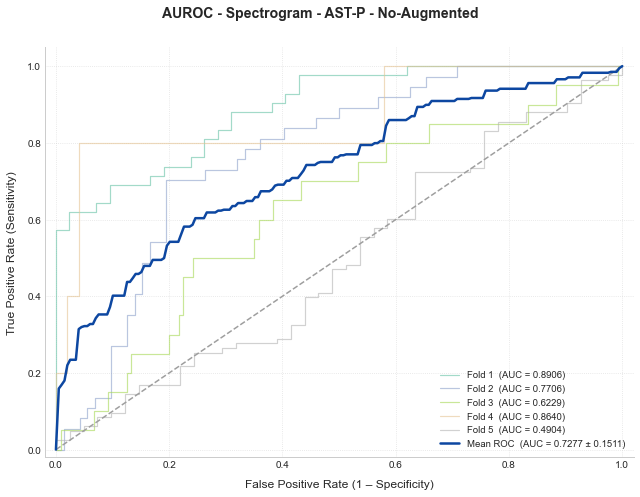

C:\Users\MxnlodyX\AppData\Local\Temp\ipykernel_33280\1823107846.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_cm.tight_layout()


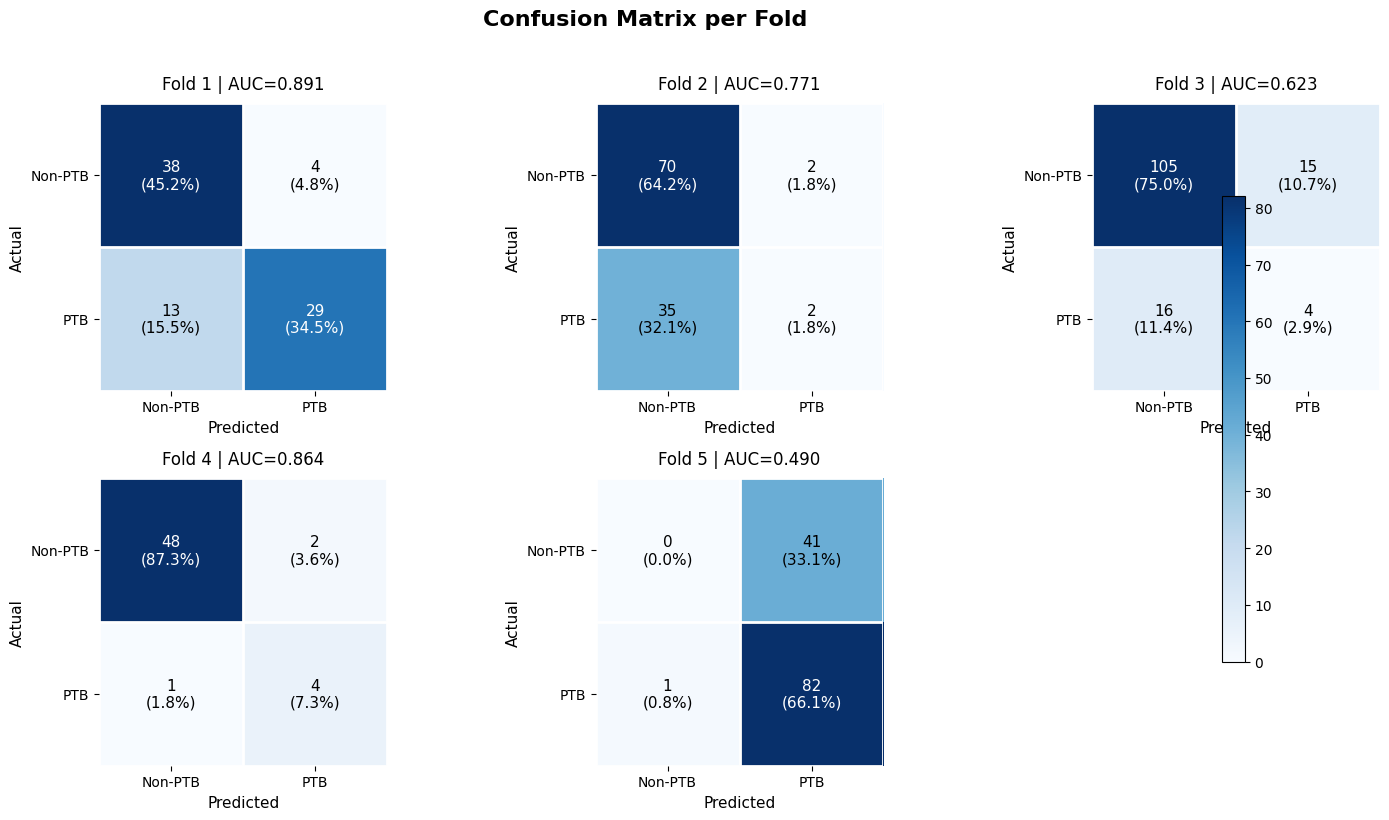


[✓] ROC plot saved → d:\AST-With-TB-Classify\exp\tb_ast-p_KFold_No_augmented\plots\roc_per_run.png
[✓] Confusion matrix per fold plot saved → d:\AST-With-TB-Classify\exp\tb_ast-p_KFold_No_augmented\plots\confusion_matrix_per_fold.png

═══════════════════════════════════════════════════════
  AUC SUMMARY
───────────────────────────────────────────────────────
  Fold 1 :  sklearn AUC = 0.8906
  Fold 2 :  sklearn AUC = 0.7706
  Fold 3 :  sklearn AUC = 0.6229
  Fold 4 :  sklearn AUC = 0.8640
  Fold 5 :  sklearn AUC = 0.4904
───────────────────────────────────────────────────────
  Mean   :  AUC = 0.7277
  ± Std  :       ± 0.1511
═══════════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  POOLED CONFUSION MATRIX (All Folds)
───────────────────────────────────────────────────────
              Predicted
Actual        Non-PTB   PTB
───────────────────────────────────────────────────────
Non-PTB (0)   TN= 261   FP=  64
PTB     (1)   FN=  

In [7]:
# ============================================================
# test_tb_AST-P_5SKF.ipynb
# Plot ROC / AUC Curve per Fold + Mean ± SD
# ============================================================

import os
import json
from pathlib import Path
import numpy as np
import matplotlib
%matplotlib inline

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix

# ------------------------------------------------------------------ #
# CONFIG — resolve workspace root robustly (avoid stale drive paths)
# ------------------------------------------------------------------ #
def resolve_base_dir():
    markers = ("Data", "src", "exp")
    candidates = []
    if "BASE_DIR" in globals() and globals()["BASE_DIR"]:
        candidates.append(Path(globals()["BASE_DIR"]))
    candidates.append(Path.cwd())
    candidates.append(Path("d:/AST-With-TB-Classify"))

    for start in candidates:
        if not start.exists():
            continue
        for p in [start] + list(start.parents):
            if all((p / m).exists() for m in markers):
                return str(p)
    return str(Path.cwd())

BASE_DIR  = resolve_base_dir()
EXP_ROOT  = os.path.join(BASE_DIR, "exp", "tb_ast-p_KFold_No_augmented")
FOLD_ROOT = os.path.join(BASE_DIR, "json_folds_5skf")
N_RUNS    = 5

# ------------------------------------------------------------------ #
# LOAD per-fold predictions
# ------------------------------------------------------------------ #
def load_run_predictions(run_num: int):
    """
    Try to load y_true and prob_ptb from
    exp/tb_ast-p_KFold_No_augmented/run_X/test_predictions.json
    Falls back to test_metrics.json if arrays exist there.
    """
    run_exp_dir = os.path.join(EXP_ROOT, f"run_{run_num}")

    # --- Option A: dedicated predictions file (recommended) ----------
    pred_path = os.path.join(run_exp_dir, "test_predictions.json")
    if os.path.exists(pred_path):
        with open(pred_path) as f:
            d = json.load(f)
        return (
            np.array(d["y_true"]),
            np.array(d["prob_ptb"]),
            d.get("threshold", 0.5),
            d.get("auroc", None),
        )

    # --- Option B: test_metrics.json (may not have raw arrays) -------
    metrics_path = os.path.join(run_exp_dir, "test_metrics.json")
    if os.path.exists(metrics_path):
        with open(metrics_path) as f:
            d = json.load(f)
        if "y_true" in d and "prob_ptb" in d:
            return (
                np.array(d["y_true"]),
                np.array(d["prob_ptb"]),
                d.get("threshold", 0.5),
                d.get("auroc", None),
            )

    raise FileNotFoundError(
        f"[Fold {run_num}] Cannot find prediction arrays.\n"
        f"  Expected: {pred_path}\n"
        f"  Or arrays in: {metrics_path}\n"
        f"  → Re-run Step 3 of the pipeline and save y_true/prob_ptb."
    )


# ------------------------------------------------------------------ #
# If all_run_metrics is already in memory (run from same kernel),
# use it directly — otherwise load from disk.
# ------------------------------------------------------------------ #
try:
    assert "all_run_metrics" in dir() or "all_run_metrics" in globals()
    _ = all_run_metrics[0]["y_true"]
    print("[✓] Using all_run_metrics from memory.")
    run_data = [
        (
            np.array(m["y_true"]),
            np.array(m["prob_ptb"]),
            m["threshold"],
            m["auroc"],
        )
        for m in all_run_metrics
    ]
except Exception:
    print("[i] Loading predictions from disk ...")
    run_data = [load_run_predictions(r) for r in range(1, N_RUNS + 1)]

# ------------------------------------------------------------------ #
# COMPUTE ROC per Fold
# ------------------------------------------------------------------ #
mean_fpr   = np.linspace(0, 1, 200)
tpr_interp = []
run_fprs, run_tprs, run_aucs, run_thresholds = [], [], [], []
fold_cms = []

# Pooled confusion matrix (using each fold's own operating threshold)
macro_tn = macro_fp = macro_fn = macro_tp = 0

for idx, (y_true, prob_ptb, opt_thresh, stored_auroc) in enumerate(run_data):
    fpr, tpr, thresholds_roc = roc_curve(y_true, prob_ptb, pos_label=1)
    auroc_val = roc_auc_score(y_true, prob_ptb)  # sklearn AUROC

    tpr_i = np.interp(mean_fpr, fpr, tpr)
    tpr_i[0] = 0.0
    tpr_interp.append(tpr_i)

    youden_j   = tpr - fpr
    best_idx   = np.argmax(youden_j)
    thresh_fpr = fpr[best_idx]
    thresh_tpr = tpr[best_idx]

    run_fprs.append(fpr)
    run_tprs.append(tpr)
    run_aucs.append(auroc_val)
    run_thresholds.append((thresh_fpr, thresh_tpr, opt_thresh))

    y_pred = (prob_ptb >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fold_cms.append(np.array([[tn, fp], [fn, tp]], dtype=int))

    macro_tn += int(tn)
    macro_fp += int(fp)
    macro_fn += int(fn)
    macro_tp += int(tp)

    print(
        f"  Fold {idx+1}: sklearn AUROC = {auroc_val:.4f}  |  "
        f"Threshold (Youden) = {opt_thresh:.4f}  "
        f"→ FPR={thresh_fpr:.3f}, TPR={thresh_tpr:.3f}"
    )

tpr_interp = np.array(tpr_interp)
mean_tpr   = tpr_interp.mean(axis=0)
mean_tpr[-1] = 1.0
std_tpr    = tpr_interp.std(axis=0)
mean_auc   = np.mean(run_aucs)
std_auc    = np.std(run_aucs)

# ------------------------------------------------------------------ #
# PLOT — Single Combined Graph (Beautified)
# ------------------------------------------------------------------ #
plt.style.use('seaborn-whitegrid') # สำหรับ matplotlib เวอร์ชันเก่า
cmap = plt.cm.get_cmap("Set2", N_RUNS)  # ใช้ชุดสีที่ดูนุ่มนวล

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle(
    "AUROC - Spectrogram - AST-P - No-Augmented\n",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

# ── Individual ROC curves (faded) ──────────────────────────────── #
for i, (fpr_i, tpr_i, auroc_i) in enumerate(zip(run_fprs, run_tprs, run_aucs)):
    ax.plot(
        fpr_i,
        tpr_i,
        color=cmap(i),
        linewidth=1.2,
        alpha=0.6,
        linestyle="-",
        label=f"Fold {i+1}  (AUC = {auroc_i:.4f})",
    )

# ── Mean ROC curve ─────────────────────────────────────────────── #
ax.plot(
    mean_fpr,
    mean_tpr,
    color="#0D47A1",
    linewidth=2.5,
    label=f"Mean ROC  (AUC = {mean_auc:.4f} ± {std_auc:.4f})",
    zorder=10
)

# ── Standard Deviation Shading ─────────────────────────────────── #


# ── Random baseline ────────────────────────────────────────────── #
ax.plot([0, 1], [0, 1], color="#9E9E9E", linestyle="--", linewidth=1.5)

# ── Axes formatting ────────────────────────────────────────────── #
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel("False Positive Rate (1 – Specificity)", fontsize=12, labelpad=10)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12, labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc="lower right", fontsize=9.5, framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

# ------------------------------------------------------------------ #
# SAVE
# ------------------------------------------------------------------ #
plot_dir  = os.path.join(EXP_ROOT, "plots")
os.makedirs(plot_dir, exist_ok=True)
plot_path = os.path.join(plot_dir, "roc_per_run.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# ------------------------------------------------------------------ #
# PLOT — Confusion Matrix per Fold (Beautified)
# ------------------------------------------------------------------ #
plt.style.use('default') # ปิดสไตล์ Grid สำหรับกราฟ Confusion Matrix
n_cols = 3
n_rows = int(np.ceil(N_RUNS / n_cols))
fig_cm, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for i in range(len(axes)):
    ax_cm = axes[i]
    if i >= N_RUNS:
        ax_cm.axis("off")
        continue

    cm = fold_cms[i]
    im = ax_cm.imshow(cm, interpolation="nearest", cmap="Blues")

    total = cm.sum()
    for r in range(2):
        for c in range(2):
            val = cm[r, c]
            pct = (100.0 * val / total) if total > 0 else 0.0
            color = "white" if val > (cm.max() * 0.5) else "black"
            # ปรับ Font ของตัวเลขในตารางให้สวยขึ้น
            ax_cm.text(c, r, f"{val}\n({pct:.1f}%)", ha="center", va="center", color=color, fontsize=11, fontweight="medium")

    ax_cm.set_xticks([0, 1])
    ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(["Non-PTB", "PTB"], fontsize=10)
    ax_cm.set_yticklabels(["Non-PTB", "PTB"], fontsize=10)
    ax_cm.set_xlabel("Predicted", fontsize=11)
    ax_cm.set_ylabel("Actual", fontsize=11)
    ax_cm.set_title(f"Fold {i+1} | AUC={run_aucs[i]:.3f}", fontsize=12, pad=10)
    
    # ลบขอบตารางนิดหน่อยให้ดูนุ่มนวล
    for edge, spine in ax_cm.spines.items():
        spine.set_visible(False)
    ax_cm.set_xticks(np.arange(cm.shape[1]+1)-.5, minor=True)
    ax_cm.set_yticks(np.arange(cm.shape[0]+1)-.5, minor=True)
    ax_cm.grid(which="minor", color="white", linestyle='-', linewidth=2)
    ax_cm.tick_params(which="minor", bottom=False, left=False)

# ปรับขนาด Colorbar ให้ดูสมดุล
fig_cm.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.04)
fig_cm.suptitle("Confusion Matrix per Fold", fontsize=16, fontweight="bold", y=1.02)
fig_cm.tight_layout()

cm_plot_path = os.path.join(plot_dir, "confusion_matrix_per_fold.png")
fig_cm.savefig(cm_plot_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# ------------------------------------------------------------------ #
# PRINT SUMMARY
# ------------------------------------------------------------------ #
print(f"\n[✓] ROC plot saved → {plot_path}")
print(f"[✓] Confusion matrix per fold plot saved → {cm_plot_path}")
print(f"\n{'═'*55}")
print("  AUC SUMMARY")
print(f"{'─'*55}")
for i, a in enumerate(run_aucs):
    print(f"  Fold {i+1} :  sklearn AUC = {a:.4f}")
print(f"{'─'*55}")
print(f"  Mean   :  AUC = {mean_auc:.4f}")
print(f"  ± Std  :       ± {std_auc:.4f}")
print(f"{'═'*55}")

print(f"\n{'═'*55}")
print("  POOLED CONFUSION MATRIX (All Folds)")
print(f"{'─'*55}")
print("              Predicted")
print("Actual        Non-PTB   PTB")
print(f"{'─'*55}")
print(f"Non-PTB (0)   TN={macro_tn:4d}   FP={macro_fp:4d}")
print(f"PTB     (1)   FN={macro_fn:4d}   TP={macro_tp:4d}")
print(f"{'─'*55}")
macro_total = macro_tn + macro_fp + macro_fn + macro_tp
macro_acc = (macro_tn + macro_tp) / macro_total if macro_total > 0 else 0.0
macro_sens = macro_tp / (macro_tp + macro_fn) if (macro_tp + macro_fn) > 0 else 0.0
macro_spec = macro_tn / (macro_tn + macro_fp) if (macro_tn + macro_fp) > 0 else 0.0
print(f"Accuracy    : {macro_acc*100:.2f}%")
print(f"Sensitivity : {macro_sens*100:.2f}%")
print(f"Specificity : {macro_spec*100:.2f}%")
print(f"{'═'*55}")